# Fig S2 — Cohort modality matrix, QC, compartment tSNEs, phenotype landscape, and IMC protein validation

Execute cells in order.

Set `DLBCL_DATA_DIR` before the setup cell to override the data root.
Example: `DLBCL_DATA_DIR = '/path/to/data'`

In [1]:
%matplotlib inline

import os
import sys
from pathlib import Path

NOTEBOOK_DIR = Path.cwd().resolve()
REPO_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from dlbcl.notebook_setup import run_notebook_setup

_ctx = run_notebook_setup('discovery_archetype', 'supplemental_fig2')
REPO_ROOT = _ctx.repo_root
_paths = _ctx.paths
FIG_DIR = _ctx.fig_dir
adata = _ctx.adata
arch_df = _ctx.arch_df
pred = _ctx.pred
gep = _ctx.gep
surv = _ctx.surv
archetype_label = _ctx.archetype_label
PATIENT_SUBSET = _ctx.patient_subset
OUTDIR = FIG_DIR
OUTDIR.mkdir(parents=True, exist_ok=True)

# Override data root: export DLBCL_DATA_DIR=/path/to/data before running.
print(f"AnnData: {_paths.adata_path}")
print(f"Figures: {FIG_DIR}")

import gc

import pandas as pd
import scanpy as sc

ADATA_PATH = _paths.adata_path

# tSNE panel constants and filtered single-cell subset.
import gc

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc

from dlbcl.dlbcl_io import consolidate_embedded_case_classifications, log_wrote, log_saved, rel_path
from dlbcl.phenotype_labels import ensure_phenotype_30_labels, read_celltype_colormap_30
from dlbcl.tsne_figures import show_inline_preview

DATA_DIR = _paths.data_dir
ADATA_PATH = _paths.adata_path
ARCH_PATH = _paths.arch_path
FILTERING_STATUS_COL = "filtering_status"
FILTERING_KEEP_VALUE = "Unfiltered"
TSNE_BASIS = "tsne_all"
DOWNSAMPLE_FRAC = 1
PLOT_SEED = 42
INLINE_PREVIEW_DPI = 96
INLINE_PREVIEW_MAX_WIDTH = 900
INLINE_PREVIEW_JPEG_QUALITY = 72

from scipy import sparse

import matplotlib as mpl

mpl.rcParams["svg.fonttype"] = "none"
mpl.rcParams["font.family"] = "DejaVu Sans"
IMC_LAYER = "sum_unhuddle"

adata_backed = ad.read_h5ad(_paths.adata_path, backed="r")
mask = (
    adata_backed.obs["patient_id"].isin(PATIENT_SUBSET)
    & (adata_backed.obs[FILTERING_STATUS_COL] == FILTERING_KEEP_VALUE)
)
adata_subset = adata_backed[mask].to_memory()
ensure_phenotype_30_labels(adata_subset)
ensure_phenotype_30_labels(adata)
del adata_backed
gc.collect()

if TSNE_BASIS not in adata_subset.obsm:
    raise KeyError(f"Missing obsm['{TSNE_BASIS}']; keys: {list(adata_subset.obsm.keys())}")

adata_subset = consolidate_embedded_case_classifications(
    adata_subset, _paths, repo_root=REPO_ROOT
)
print(
    f"Cells: {adata_subset.n_obs:,} | patients: {adata_subset.obs['patient_id'].nunique()}"
)

from IPython.display import display
from dlbcl.dlbcl_io import log_wrote, log_saved, rel_path, write_supplementary_table
subset = None  # nb8 classifier associations: filtered AnnData or None for all patients

from dlbcl.dlbcl_io import load_omiq_tsne
from dlbcl.phenotype_labels import ensure_phenotype_30_labels


AnnData: /Users/troynoordenbos/code/public_repo/DLBCL_location_2026/data/DLBCL_location_2026.h5ad
Figures: /Users/troynoordenbos/code/public_repo/DLBCL_location_2026/figures/supplemental_fig2


Cells: 1,192,844 | patients: 64


## Fig S2 — panel overview

Panels follow manuscript order (S2A → S2E → S2G–I → S2J → S2K → S2L → S2M).

| Panel | Description |
|-------|-------------|
| S2A | Discovery / validation cohort modality matrix |
| S2E | QC filtering tSNE (discovery patients; pre- and post-filter cells) |
| S2G | CD8 compartment sub-tSNE (OMIQ opt-SNE) |
| S2H | CD4 compartment sub-tSNE |
| S2I | Myeloid compartment sub-tSNE |
| S2J | Tonsil reference segmentation overlay — see **`fig3.ipynb`** |
| S2K | 30-class phenotype tSNE (`phenotype_30_bm`) |
| S2L | Phenotype × protein heatmap (30-class, fine) |
| S2M | Phenotype × protein heatmap (16-class, coarse) |

Gene–protein correlation scatters (**Fig S3A**) are in `supplemental_fig3.ipynb`. The elastic-net classifier confusion matrix (**Fig 5H**, supplement **Fig S3J** pointer) is in `fig5.ipynb`.

**Data:** `data/DLBCL_location_2026.h5ad` — set `DLBCL_DATA_DIR` to override the data root.

## Fig S2A — cohort modality matrix

**V3** (`figS2A_cohort_modality_matrix_v3.svg`): per-site patient strips with matched per-patient column width across discovery and validation cohorts.

Discovery by site: {'PCNS': 19, 'bone': 20, 'nodal': 16, 'testis': 9} (n=64)
Validation by site: {'PCNS': 130, 'bone': 51, 'nodal': 64, 'testis': 63} (n=308)


,discovery_n,validation_n
Clinical data,64,308
Survival,59,308
Histology,64,308
Genomic profiling,61,218
Transcriptomic profiling,64,308
IHC tumor profiling,64,306
IMC multiplex,64,0


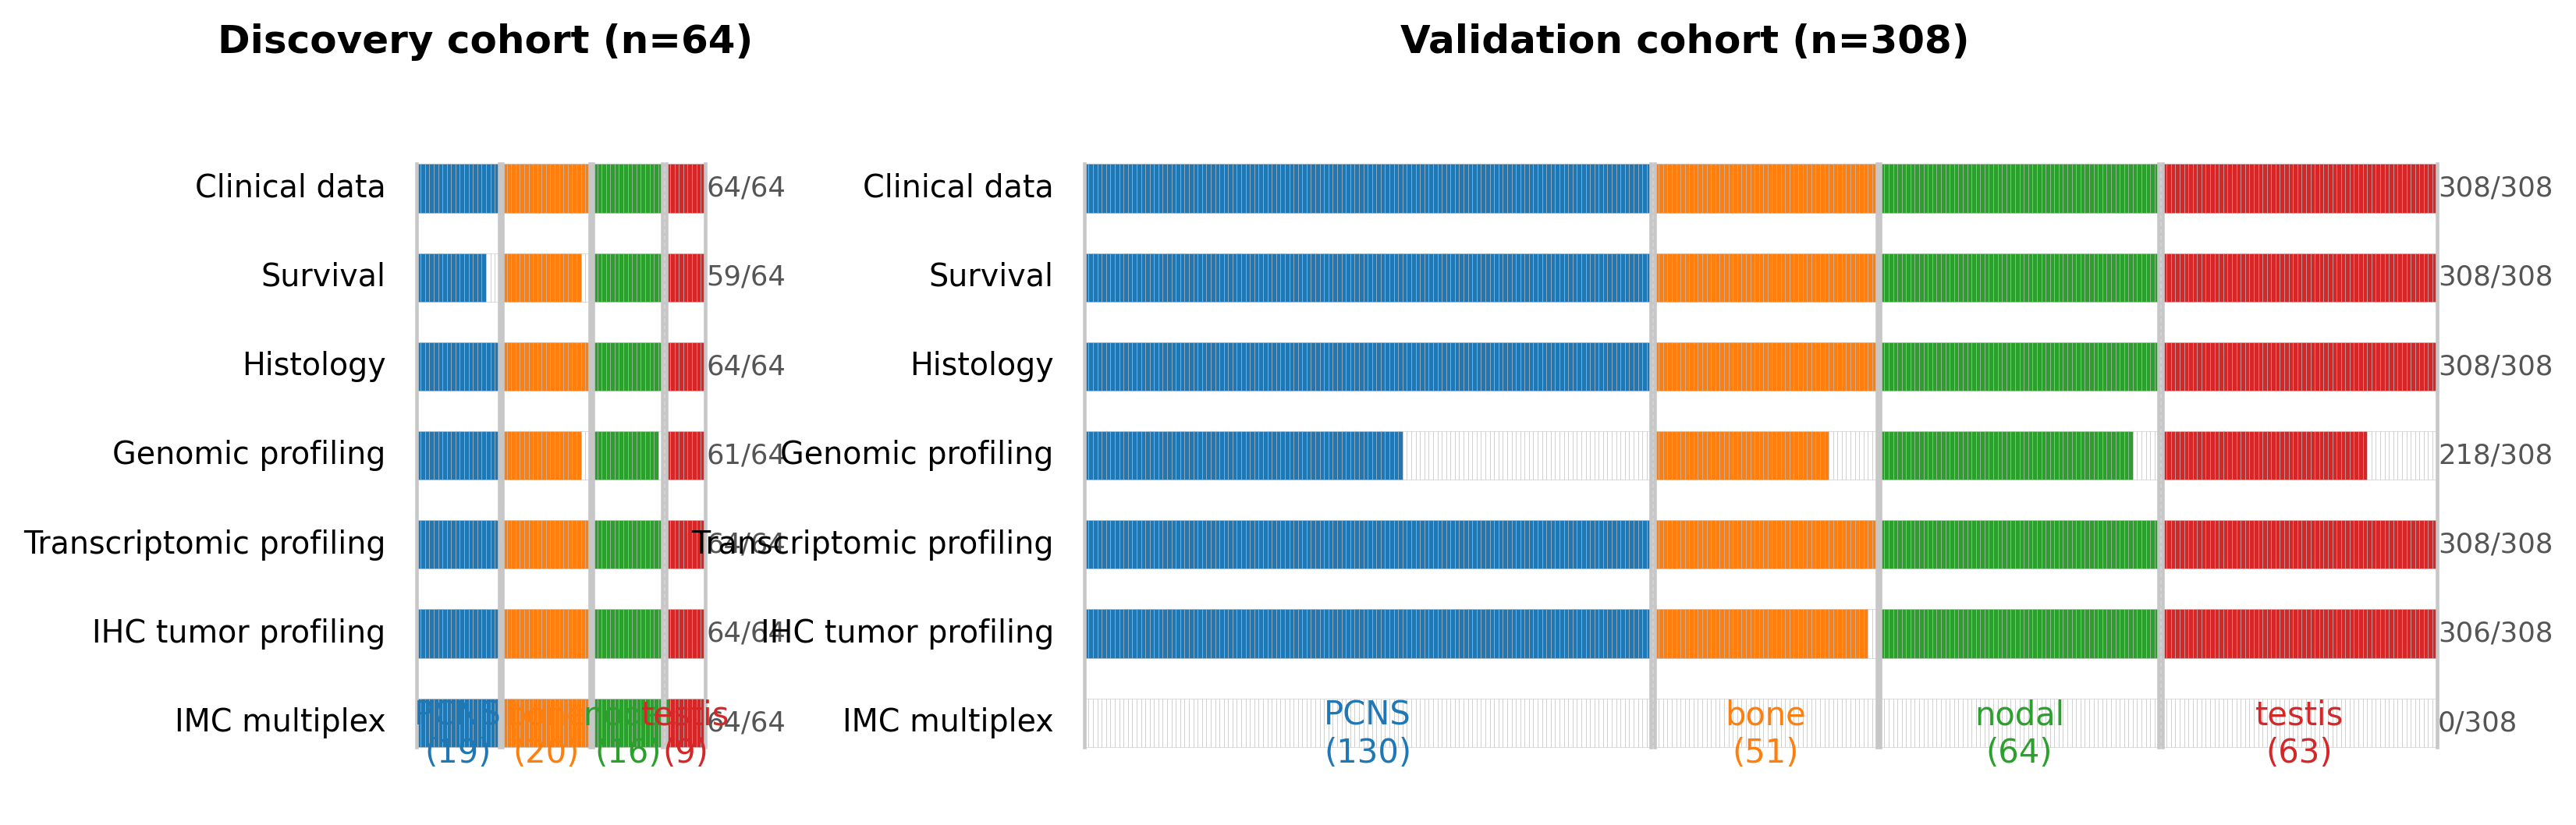

/Users/troynoordenbos/code/public_repo/DLBCL_location_2026/figures/supplemental_fig2/fig1C_cohort_modality_matrix_v3.svg


In [2]:
from IPython.display import Image, display

from dlbcl.cohort_modality_matrix import (
    DISCOVERY_MODALITY_ROWS,
    build_discovery_patient_matrix,
    build_validation_patient_matrix,
    discovery_location_counts,
    save_fig1c_v1,
    save_fig1c_v2,
    save_fig1c_v3,
    validation_location_counts,
)

# Row / modality rules: cohort_modality_matrix.py (validation genomic_tested from
# adata.uns['validation_cohort']['ngs_data'] patient_alias).

# V2/V3 layout — set patient_cell_w to fix column width (data units); None = automatic
FIG1C_PATIENT_CELL_W = 0.05
FIG1C_PANEL_WIDTH = 6.5  # reference panel width when patient_cell_w is None

discovery_counts = discovery_location_counts(adata_subset)
validation_counts = validation_location_counts(adata_subset)
print(f"Discovery by site: {discovery_counts} (n={sum(discovery_counts.values())})")
print(f"Validation by site: {validation_counts} (n={sum(validation_counts.values())})")

d_matrix = build_discovery_patient_matrix(adata_subset)
v_matrix = build_validation_patient_matrix(adata_subset)
d_totals = d_matrix.sum()
v_totals = v_matrix.sum()
summary = pd.DataFrame(
    {
        "discovery_n": [int(d_totals[r.key]) for r in DISCOVERY_MODALITY_ROWS],
        "validation_n": [int(v_totals[r.key]) for r in DISCOVERY_MODALITY_ROWS],
    },
    index=[r.label for r in DISCOVERY_MODALITY_ROWS],
)
display(summary)

# V2 — per-site patient strips (each cohort fills its panel width)
#v2_svg, v2_png = save_fig1c_v2(
#    adata_subset,
#    FIG_DIR,
#    patient_cell_w=FIG1C_PATIENT_CELL_W,
#    panel_width=FIG1C_PANEL_WIDTH,
#)
#display(Image(filename=str(v2_png)))
#print(v2_svg)

# V3 — like V2 but matched per-patient column width across cohorts
v3_svg, v3_png = save_fig1c_v3(
    adata_subset,
    FIG_DIR,
    patient_cell_w=FIG1C_PATIENT_CELL_W,
    panel_width=FIG1C_PANEL_WIDTH,
)
display(Image(filename=str(v3_png)))
print(v3_svg)


## Shared tSNE plotting helpers

In [3]:
from dlbcl.tsne_figures import save_figure as _save_tsne_figure


def save_figure(fig, stem: Path):
    """Delegate to shared tSNE saver (honors DLBCL_TSNE_RASTER_ONLY)."""
    _save_tsne_figure(
        fig,
        Path(stem),
        repo_root=REPO_ROOT,
        preview=True,
    )


def downsample_indices(n_obs: int, frac: float = DOWNSAMPLE_FRAC, seed: int = PLOT_SEED) -> np.ndarray:
    rng = np.random.default_rng(seed)
    n_plot = max(1, int(round(n_obs * frac)))
    return rng.choice(n_obs, size=n_plot, replace=False)


def valid_label_mask(series: pd.Series, extra_exclude=()) -> pd.Series:
    s = series.astype(str)
    mask = series.notna() & (s != "")
    for bad in ("NA", "unknown", "0", *extra_exclude):
        mask &= ~s.str.contains(rf"\b{bad}\b", case=False, na=False)
    return mask


def plot_tsne(
    adata_plot,
    color: str,
    title: str,
    out_stem: Path,
    palette=None,
    sort_order=None,
    alpha: float = 0.7,
    size: float = 1,
):
    kwargs = dict(
        basis=TSNE_BASIS,
        color=color,
        title=title,
        show=False,
        alpha=alpha,
        size=size,
        return_fig=True,
    )
    if palette is not None:
        kwargs["palette"] = palette
    if sort_order is not None:
        kwargs["sort_order"] = sort_order
    fig = sc.pl.embedding(adata_plot, **kwargs)
    save_figure(fig, out_stem)
    plt.close(fig)
    gc.collect()


def map_patient_column(adata, uns_key: str, obs_col: str):
    adata.obs[obs_col] = adata.obs["patient_id"].map(adata.uns["case_classifications"][uns_key])
    return adata


def sort_adata_by_obs_category(adata, col: str):
    """Stable row order for categorical obs columns (pandas 2.x safe)."""
    clusters = adata.obs[col].value_counts().index.tolist()
    codes = pd.Categorical(adata.obs[col], categories=clusters, ordered=True).codes
    return adata[np.argsort(codes, kind="stable")].copy()


## Fig S2E — QC filtering tSNE

/Users/troynoordenbos/code/public_repo/DLBCL_location_2026/.venv/lib/python3.14/site-packages/scanpy/plotting/_utils.py:509: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


figures/supplemental_fig2/figS2E_tsne_qc_filtering.svg


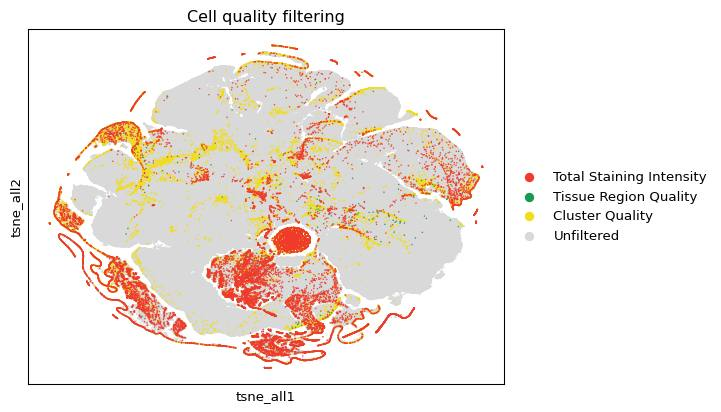

0

In [4]:
adata_qc_backed = ad.read_h5ad(ADATA_PATH, backed="r")

qc_cols = [
    "QC_low_intensity_filter",
    "QC_filter_low_quality_region",
    "QC_dr_based_filter",
]
mask_qc = adata_qc_backed.obs["patient_id"].isin(PATIENT_SUBSET)
obs_qc = adata_qc_backed.obs.loc[mask_qc, qc_cols].copy()
emb_qc = np.asarray(adata_qc_backed.obsm[TSNE_BASIS])[mask_qc.to_numpy()]
del adata_qc_backed
gc.collect()

adata_qc = ad.AnnData(
    X=np.zeros((obs_qc.shape[0], 1), dtype=np.float32),
    obs=obs_qc,
    obsm={TSNE_BASIS: emb_qc},
)

qc_low_int = adata_qc.obs["QC_low_intensity_filter"].fillna(False).astype(bool)
qc_low_qr = adata_qc.obs["QC_filter_low_quality_region"].fillna(False).astype(bool)
qc_dr = adata_qc.obs["QC_dr_based_filter"].fillna(False).astype(bool)

adata_qc.obs["filtering_label"] = "Unfiltered"
adata_qc.obs.loc[qc_low_int, "filtering_label"] = "Total Staining Intensity"
adata_qc.obs.loc[qc_low_qr, "filtering_label"] = "Tissue Region Quality"
adata_qc.obs.loc[qc_dr, "filtering_label"] = "Cluster Quality"

filter_order = [
    "Total Staining Intensity",
    "Tissue Region Quality",
    "Cluster Quality",
    "Unfiltered",
]
adata_qc.obs["filtering_label"] = pd.Categorical(adata_qc.obs["filtering_label"], categories=filter_order, ordered=True)

plot_order = ["Unfiltered", "Cluster Quality", "Tissue Region Quality", "Total Staining Intensity"]
order_key = {k: i for i, k in enumerate(plot_order)}
adata_plot = adata_qc[np.argsort(adata_qc.obs["filtering_label"].astype(str).map(order_key))]

rng = np.random.default_rng(PLOT_SEED)
is_unf = adata_plot.obs["filtering_label"] == "Unfiltered"
idx_unf = np.where(is_unf)[0]
idx_filt = np.where(~is_unf)[0]
keep_unf = rng.choice(idx_unf, size=max(1, int(round(len(idx_unf) * DOWNSAMPLE_FRAC))), replace=False)
keep_idx = np.concatenate([keep_unf, idx_filt])
adata_plot = adata_plot[keep_idx]
adata_plot = adata_plot[np.argsort(adata_plot.obs["filtering_label"].astype(str).map(order_key))]

filter_palette = {
    "Total Staining Intensity": "#ef3b2c",
    "Tissue Region Quality": "#1a9850",
    "Cluster Quality": "#f1dd19",
    "Unfiltered": "#d9d9d9",
}

fig = sc.pl.embedding(
    adata_plot,
    basis=TSNE_BASIS,
    color="filtering_label",
    title="Cell quality filtering",
    palette=filter_palette,
    show=False,
    alpha=0.9,
    size=5,
    return_fig=True,
)
save_figure(fig, FIG_DIR / "figS2E_tsne_qc_filtering")
plt.close(fig)
gc.collect()

del adata_qc, adata_plot, obs_qc, emb_qc
gc.collect()


In [5]:
# Compartment sub-tSNE panels (S2G–I) use all unfiltered single cells.
from dlbcl.phenotype_labels import ensure_phenotype_30_labels

adata = adata[adata.obs[FILTERING_STATUS_COL] == FILTERING_KEEP_VALUE].copy()
ensure_phenotype_30_labels(adata)
print(f"Compartment tSNE cells: {adata.n_obs:,} | patients: {adata.obs['patient_id'].nunique()}")


Compartment tSNE cells: 1,316,220 | patients: 71


## Fig S2G — CD8 sub-tSNE

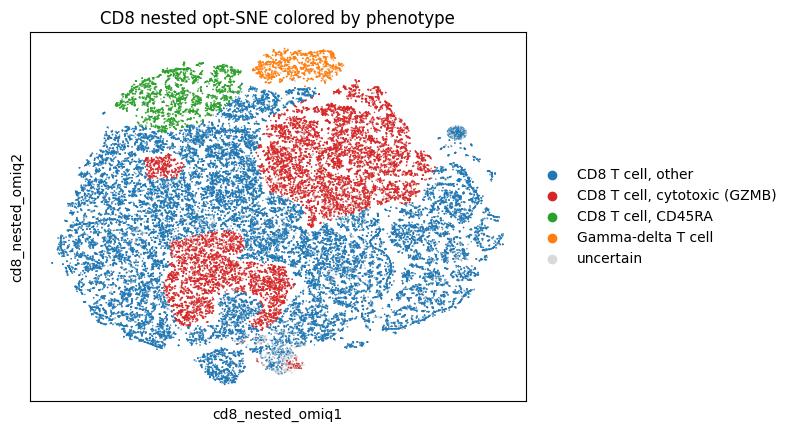

Cells plotted: 66,866
Saved to: figures/supplemental_fig2

Counts:
phenotype_cd8_lumped
CD8 T cell, other               37286
CD8 T cell, cytotoxic (GZMB)    16123
uncertain                        8473
CD8 T cell, CD45RA               3364
Gamma-delta T cell               1620
Name: count, dtype: int64


In [6]:
from pathlib import Path
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad

OUTDIR = FIG_DIR
OUTDIR.mkdir(parents=True, exist_ok=True)

df = load_omiq_tsne(adata, "cd8")

# --------------------------------------------------
# Map phenotype from original adata
# --------------------------------------------------
if "phenotype_30_clean" not in adata.obs.columns:
    raise KeyError("adata.obs['phenotype_30_clean'] not found")

if not adata.obs.index.is_unique:
    raise ValueError("adata.obs.index is not unique")

pheno_map = adata.obs["phenotype_30_clean"].astype(str)
df["phenotype_30_clean"] = df["cell_id"].map(pheno_map)

# --------------------------------------------------
# Keep CD8 phenotypes, lump everything else as uncertain
# --------------------------------------------------
cd8_labels = [
    "CD8 T cell, other",
    "CD8 T cell, cytotoxic (GZMB)",
    "CD8 T cell, CD45RA",
    "Gamma-delta T cell",
]

pheno = df["phenotype_30_clean"].fillna("Missing in adata").astype(str)
keep_mask = pheno.isin(cd8_labels)

df["phenotype_cd8_lumped"] = np.where(
    keep_mask,
    pheno,
    "uncertain",
)

order = cd8_labels + ["uncertain"]

present = [x for x in order if x in set(df["phenotype_cd8_lumped"])]
extra = sorted(set(df["phenotype_cd8_lumped"]) - set(present))

df["phenotype_cd8_lumped"] = pd.Categorical(
    df["phenotype_cd8_lumped"],
    categories=present + extra,
    ordered=True,
)

# --------------------------------------------------
# Save annotated table + counts
# --------------------------------------------------
annotated_csv = OUTDIR / "cd8_nested_optsne_with_lumped_phenotypes.csv"
counts_csv = OUTDIR / "cd8_nested_optsne_lumped_phenotype_counts.csv"

df.to_csv(annotated_csv, index=False)

counts = (
    df["phenotype_cd8_lumped"]
    .value_counts()
    .rename_axis("phenotype_cd8_lumped")
    .reset_index(name="n_cells")
)

counts["pct"] = (100 * counts["n_cells"] / counts["n_cells"].sum()).round(2)
counts.to_csv(counts_csv, index=False)

# --------------------------------------------------
# Build temporary AnnData for Scanpy plotting
# --------------------------------------------------
adata_cd8_plot = ad.AnnData(
    X=np.zeros((len(df), 1), dtype=np.float32),
    obs=df.set_index("cell_id")[[
        "phenotype_30_clean",
        "phenotype_cd8_lumped",
    ]],
)

adata_cd8_plot.obsm["X_cd8_nested_omiq"] = df[
    ["optsne_1", "optsne_2"]
].to_numpy(dtype=np.float32)

# --------------------------------------------------
# Palette
# --------------------------------------------------
palette = {
    "CD8 T cell, other": "#1f77b4",
    "CD8 T cell, cytotoxic (GZMB)": "#d62728",
    "CD8 T cell, CD45RA": "#2ca02c",
    "Gamma-delta T cell": "#ff7f0e",
    "uncertain": "#d9d9d9",
}

palette_present = {
    k: v for k, v in palette.items()
    if k in adata_cd8_plot.obs["phenotype_cd8_lumped"].cat.categories
}

# --------------------------------------------------
# Plot with Scanpy
# --------------------------------------------------
fig = sc.pl.embedding(
    adata_cd8_plot,
    basis="cd8_nested_omiq",
    color="phenotype_cd8_lumped",
    title="CD8 nested opt-SNE colored by phenotype",
    show=False,
    palette=palette_present,
    alpha=0.8,
    size=5,
    return_fig=True,
)

fig.savefig(
    OUTDIR / "cd8_nested_optsne_scanpy_lumped_phenotypes.png",
    dpi=300,
    bbox_inches="tight",
)

fig.savefig(
    OUTDIR / "cd8_nested_optsne_scanpy_lumped_phenotypes.pdf",
    bbox_inches="tight",
)

plt.show()
print(f"Cells plotted: {adata_cd8_plot.n_obs:,}")
print(f"Saved to: {rel_path(OUTDIR, REPO_ROOT)}")

print("\nCounts:")
print(adata_cd8_plot.obs["phenotype_cd8_lumped"].value_counts())

## Fig S2H — CD4 sub-tSNE

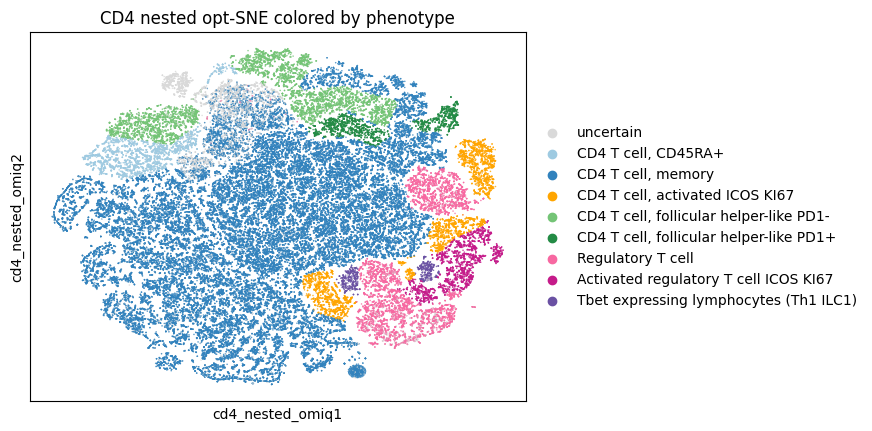

Saved to: figures/supplemental_fig2
phenotype_cd4_lumped
CD4 T cell, memory                         57828
uncertain                                   7574
CD4 T cell, follicular helper-like PD1-     6455
Regulatory T cell                           6187
CD4 T cell, activated ICOS KI67             4224
CD4 T cell, CD45RA+                         2926
Activated regulatory T cell ICOS KI67       2515
CD4 T cell, follicular helper-like PD1+     2186
Tbet expressing lymphocytes (Th1 ILC1)       882
Name: count, dtype: int64


In [7]:
from pathlib import Path
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad

OUTDIR = FIG_DIR
OUTDIR.mkdir(parents=True, exist_ok=True)

df = load_omiq_tsne(adata, "cd4")

# --------------------------------------------------
# Map phenotype from original adata
# --------------------------------------------------
if "phenotype_30_clean" not in adata.obs.columns:
    raise KeyError("adata.obs['phenotype_30_clean'] not found")

if not adata.obs.index.is_unique:
    raise ValueError("adata.obs.index is not unique")

pheno_map = adata.obs["phenotype_30_clean"].astype(str)
df["phenotype_30_clean"] = df["cell_id"].map(pheno_map)

# --------------------------------------------------
# Lump non-CD4/Treg/T-helper into uncertain
# --------------------------------------------------
pheno = df["phenotype_30_clean"].fillna("Missing in adata").astype(str)

keep_mask = (
    pheno.str.contains("CD4", case=False, na=False)
    | pheno.str.contains("regulatory T cell|Treg", case=False, na=False)
    | pheno.str.contains("follicular helper|helper", case=False, na=False)
    | pheno.str.contains("Th1|ILC1", case=False, na=False)
)

df["phenotype_cd4_lumped"] = np.where(keep_mask, pheno, "uncertain")

order = [
    "uncertain",
    "CD4 T cell, CD45RA+",
    "CD4 T cell, memory",
    "CD4 T cell, activated ICOS KI67",
    "CD4 T cell, follicular helper-like PD1-",
    "CD4 T cell, follicular helper-like PD1+",
    "Regulatory T cell",
    "Activated regulatory T cell ICOS KI67",
    "Tbet expressing lymphocytes (Th1 ILC1)",
]

present = [x for x in order if x in set(df["phenotype_cd4_lumped"])]
extra = sorted(set(df["phenotype_cd4_lumped"]) - set(present))

df["phenotype_cd4_lumped"] = pd.Categorical(
    df["phenotype_cd4_lumped"],
    categories=present + extra,
    ordered=True,
)

# --------------------------------------------------
# Build temporary AnnData for Scanpy plotting
# --------------------------------------------------
adata_cd4_plot = ad.AnnData(
    X=np.zeros((len(df), 1), dtype=np.float32),
    obs=df.set_index("cell_id")[["phenotype_30_clean", "phenotype_cd4_lumped"]],
)

adata_cd4_plot.obsm["X_cd4_nested_omiq"] = df[["optsne_1", "optsne_2"]].to_numpy(dtype=np.float32)

# --------------------------------------------------
# Palette
# --------------------------------------------------
palette = {
    "uncertain": "#d9d9d9",
    "CD4 T cell, CD45RA+": "#9ecae1",
    "CD4 T cell, memory": "#3182bd",
    "CD4 T cell, activated ICOS KI67": "#FFA500",
    "CD4 T cell, follicular helper-like PD1-": "#74c476",
    "CD4 T cell, follicular helper-like PD1+": "#238b45",
    "Regulatory T cell": "#f768a1",
    "Activated regulatory T cell ICOS KI67": "#c51b8a",
    "Tbet expressing lymphocytes (Th1 ILC1)": "#6a51a3",
}

palette_present = {
    k: v for k, v in palette.items()
    if k in adata_cd4_plot.obs["phenotype_cd4_lumped"].cat.categories
}

# --------------------------------------------------
# Plot with Scanpy
# --------------------------------------------------
fig = sc.pl.embedding(
    adata_cd4_plot,
    basis="cd4_nested_omiq",
    color="phenotype_cd4_lumped",
    title="CD4 nested opt-SNE colored by phenotype",
    show=False,
    palette=palette_present,
    alpha=0.8,
    size=5,
    return_fig=True,
)

fig.savefig(
    OUTDIR / "cd4_nested_optsne_scanpy_lumped_phenotypes.png",
    dpi=300,
    bbox_inches="tight",
)

fig.savefig(
    OUTDIR / "cd4_nested_optsne_scanpy_lumped_phenotypes.pdf",
    bbox_inches="tight",
)

plt.show()
print(f"Saved to: {rel_path(OUTDIR, REPO_ROOT)}")
print(adata_cd4_plot.obs["phenotype_cd4_lumped"].value_counts())

## Fig S2I — myeloid sub-tSNE

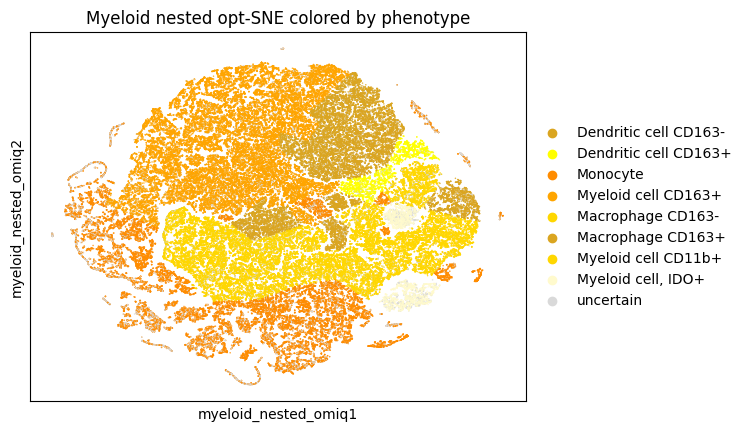

Saved to: figures/supplemental_fig2
phenotype_myeloid_lumped
Myeloid cell CD163+      34546
Macrophage CD163-        28992
Monocyte                 23320
Macrophage CD163+        16246
uncertain                15410
Dendritic cell CD163-     3176
Myeloid cell CD11b+       2631
Myeloid cell, IDO+        2478
Dendritic cell CD163+     2406
Name: count, dtype: int64


In [8]:
from pathlib import Path
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad

OUTDIR = FIG_DIR
OUTDIR.mkdir(parents=True, exist_ok=True)

df = load_omiq_tsne(adata, "myeloid")

# --------------------------------------------------
# Map phenotype from original adata
# --------------------------------------------------
if "phenotype_30_clean" not in adata.obs.columns:
    raise KeyError("adata.obs['phenotype_30_clean'] not found")

if not adata.obs.index.is_unique:
    raise ValueError("adata.obs.index is not unique")

pheno_map = adata.obs["phenotype_30_clean"].astype(str)
df["phenotype_30_clean"] = df["cell_id"].map(pheno_map)
pheno = df["phenotype_30_clean"].fillna("Missing in adata").astype(str)

# --------------------------------------------------
# Keep myeloid phenotypes, lump everything else as uncertain
# --------------------------------------------------
myeloid_labels = [
    "Dendritic cell CD163-",
    "Dendritic cell CD163+",
    "Monocyte",
    "Myeloid cell CD163+",
    "Macrophage CD163-",
    "Macrophage CD163+",
    "Myeloid cell CD11b+",
    "Myeloid cell, IDO+",
    "Neutrophils",
]

keep_mask = pheno.isin(myeloid_labels)
df["phenotype_myeloid_lumped"] = np.where(keep_mask, pheno, "uncertain")

order = myeloid_labels + ["uncertain"]
present = [x for x in order if x in set(df["phenotype_myeloid_lumped"])]
extra = sorted(set(df["phenotype_myeloid_lumped"]) - set(present))

df["phenotype_myeloid_lumped"] = pd.Categorical(
    df["phenotype_myeloid_lumped"],
    categories=present + extra,
    ordered=True,
)

# --------------------------------------------------
# Save annotated table + counts
# --------------------------------------------------
df.to_csv(OUTDIR / "myeloid_nested_optsne_with_lumped_phenotypes.csv", index=False)

counts = (
    df["phenotype_myeloid_lumped"]
    .value_counts()
    .rename_axis("phenotype_myeloid_lumped")
    .reset_index(name="n_cells")
)
counts["pct"] = (100 * counts["n_cells"] / counts["n_cells"].sum()).round(2)
counts.to_csv(OUTDIR / "myeloid_nested_optsne_lumped_phenotype_counts.csv", index=False)

# --------------------------------------------------
# Build temporary AnnData for Scanpy plotting
# --------------------------------------------------
adata_myeloid_plot = ad.AnnData(
    X=np.zeros((len(df), 1), dtype=np.float32),
    obs=df.set_index("cell_id")[["phenotype_30_clean", "phenotype_myeloid_lumped"]],
)
adata_myeloid_plot.obsm["X_myeloid_nested_omiq"] = df[["optsne_1", "optsne_2"]].to_numpy(dtype=np.float32)

# --------------------------------------------------
# Palette (reuse the 30-type colormap for consistency)
# --------------------------------------------------
cmap30 = dict(adata.uns.get("celltype_colormap_30", {}))
palette = {lab: cmap30.get(lab, "#000000") for lab in myeloid_labels}
palette["uncertain"] = "#d9d9d9"

palette_present = {
    k: v for k, v in palette.items()
    if k in adata_myeloid_plot.obs["phenotype_myeloid_lumped"].cat.categories
}

# --------------------------------------------------
# Plot with Scanpy
# --------------------------------------------------
fig = sc.pl.embedding(
    adata_myeloid_plot,
    basis="myeloid_nested_omiq",
    color="phenotype_myeloid_lumped",
    title="Myeloid nested opt-SNE colored by phenotype",
    show=False,
    palette=palette_present,
    alpha=0.8,
    size=5,
    return_fig=True,
)

fig.savefig(OUTDIR / "myeloid_nested_optsne_scanpy_lumped_phenotypes.png", dpi=300, bbox_inches="tight")
fig.savefig(OUTDIR / "myeloid_nested_optsne_scanpy_lumped_phenotypes.pdf", bbox_inches="tight")

plt.show()
print(f"Saved to: {rel_path(OUTDIR, REPO_ROOT)}")
print(adata_myeloid_plot.obs["phenotype_myeloid_lumped"].value_counts())


## Fig S2J — tonsil reference segmentation overlay

Fine-grained segmentation overlays including the tonsil reference FOV (`Tonsil394_1`) are generated in **`fig3.ipynb`** (Fig 3A–C + S2J).

Outputs: `figures/fig3/segment_img_for_overlay_{30,16}/`.

## Fig S2K — 30-class phenotype tSNE

/Users/troynoordenbos/code/public_repo/DLBCL_location_2026/.venv/lib/python3.14/site-packages/scanpy/_utils/__init__.py:472: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata._sanitize()


/Users/troynoordenbos/code/public_repo/DLBCL_location_2026/.venv/lib/python3.14/site-packages/scanpy/_utils/__init__.py:472: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata._sanitize()


figures/supplemental_fig2/figS2K_tsne_phenotype30_bm.svg


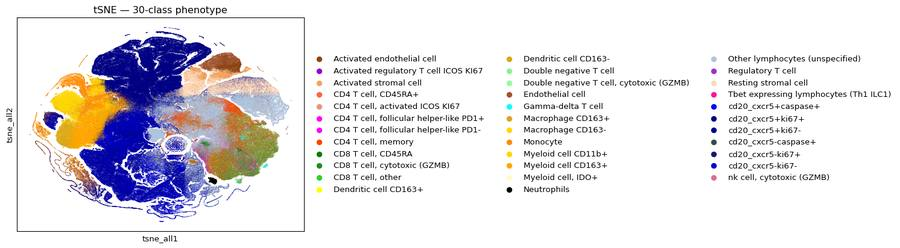

In [9]:
adata_sorted = sort_adata_by_obs_category(adata_subset, "phenotype_30_bm")
adata_plot = adata_sorted[downsample_indices(adata_sorted.n_obs)]

plot_tsne(
    adata_plot,
    color="phenotype_30_bm",
    title="tSNE — 30-class phenotype",
    out_stem=FIG_DIR / "figS2K_tsne_phenotype30_bm",
    palette=read_celltype_colormap_30(adata_sorted),
)


## Phenotype × protein heatmaps (shared helpers)

In [10]:
def _zscore_rows(mat, axis=0):
    mu = np.nanmean(mat, axis=axis, keepdims=True)
    sd = np.nanstd(mat, axis=axis, ddof=0, keepdims=True)
    sd = np.where(sd == 0, 1.0, sd)
    return (mat - mu) / sd

def _imc_matrix(adata, layer):
    if layer is None:
        return adata.X
    if layer not in adata.layers:
        raise KeyError(f"Layer '{layer}' not in adata.layers")
    return adata.layers[layer]

def build_pheno_protein_matrix(adata, pheno_col, pheno_order, proteins_order, layer=IMC_LAYER, agg="mean"):
    obs = adata.obs
    good = (
        obs[FILTERING_STATUS_COL].astype(str).eq(FILTERING_KEEP_VALUE).to_numpy()
        & obs[pheno_col].notna().to_numpy()
    )
    ph = obs.loc[good, pheno_col].astype(str)
    var_to_idx = pd.Series(np.arange(adata.n_vars), index=adata.var_names.astype(str))
    proteins = [p for p in proteins_order if p in var_to_idx.index]
    missing = [p for p in proteins_order if p not in var_to_idx.index]
    if missing:
        print(f"Skipped proteins: {missing}")
    if not proteins:
        raise ValueError("No proteins from order found in adata.var_names")

    present = pd.Index(ph.unique())
    row_order = [p for p in pheno_order if p in present] + sorted(p for p in present if p not in set(pheno_order))
    codes = pd.Categorical(ph, categories=row_order, ordered=True).codes
    X = _imc_matrix(adata, layer)[good][:, var_to_idx[proteins].to_numpy()]

    n_groups, n_prots = len(row_order), len(proteins)
    counts = np.bincount(codes[codes >= 0], minlength=n_groups)
    M = np.zeros((n_groups, n_prots))
    for g in range(n_groups):
        mask = codes == g
        if not mask.any():
            continue
        block = X[mask]
        M[g] = np.asarray(block.mean(axis=0)).ravel() if agg == "mean" else np.median(
            block.toarray() if sparse.issparse(block) else np.asarray(block), axis=0
        )
    return M, row_order, proteins, counts

def plot_pheno_protein_heatmap(Mz, row_labels, col_labels, counts, title, out_path,
                               cmap="Blues", tick_fontsize=8, title_fontsize=13):
    n_rows, n_cols = Mz.shape
    fig, ax = plt.subplots(figsize=(max(6, 0.28 * n_cols + 2), max(5, 0.28 * n_rows + 2)))
    im = ax.imshow(Mz, cmap=cmap, aspect="equal")
    ax.set_xticks(np.arange(n_cols))
    ax.set_yticks(np.arange(n_rows))
    ax.set_xticklabels(col_labels, fontsize=tick_fontsize, rotation=90, ha="center")
    ax.set_yticklabels([f"{r}  (n={int(c)})" for r, c in zip(row_labels, counts)], fontsize=tick_fontsize)
    ax.set_title(title, fontsize=title_fontsize, pad=14)
    ax.set_xticks(np.arange(-0.5, n_cols, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, n_rows, 1), minor=True)
    ax.grid(which="minor", linestyle="-", linewidth=0.3, alpha=0.25)
    ax.tick_params(which="minor", bottom=False, left=False)
    cbar = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
    cbar.set_label("Z-scored protein expression", fontsize=10)
    cbar.ax.tick_params(labelsize=8)
    plt.tight_layout()
    fig.savefig(out_path, format="svg", bbox_inches="tight")
    plt.show()
    print(rel_path(out_path, REPO_ROOT))


## Fig S2L — phenotype × protein (30-class, fine)

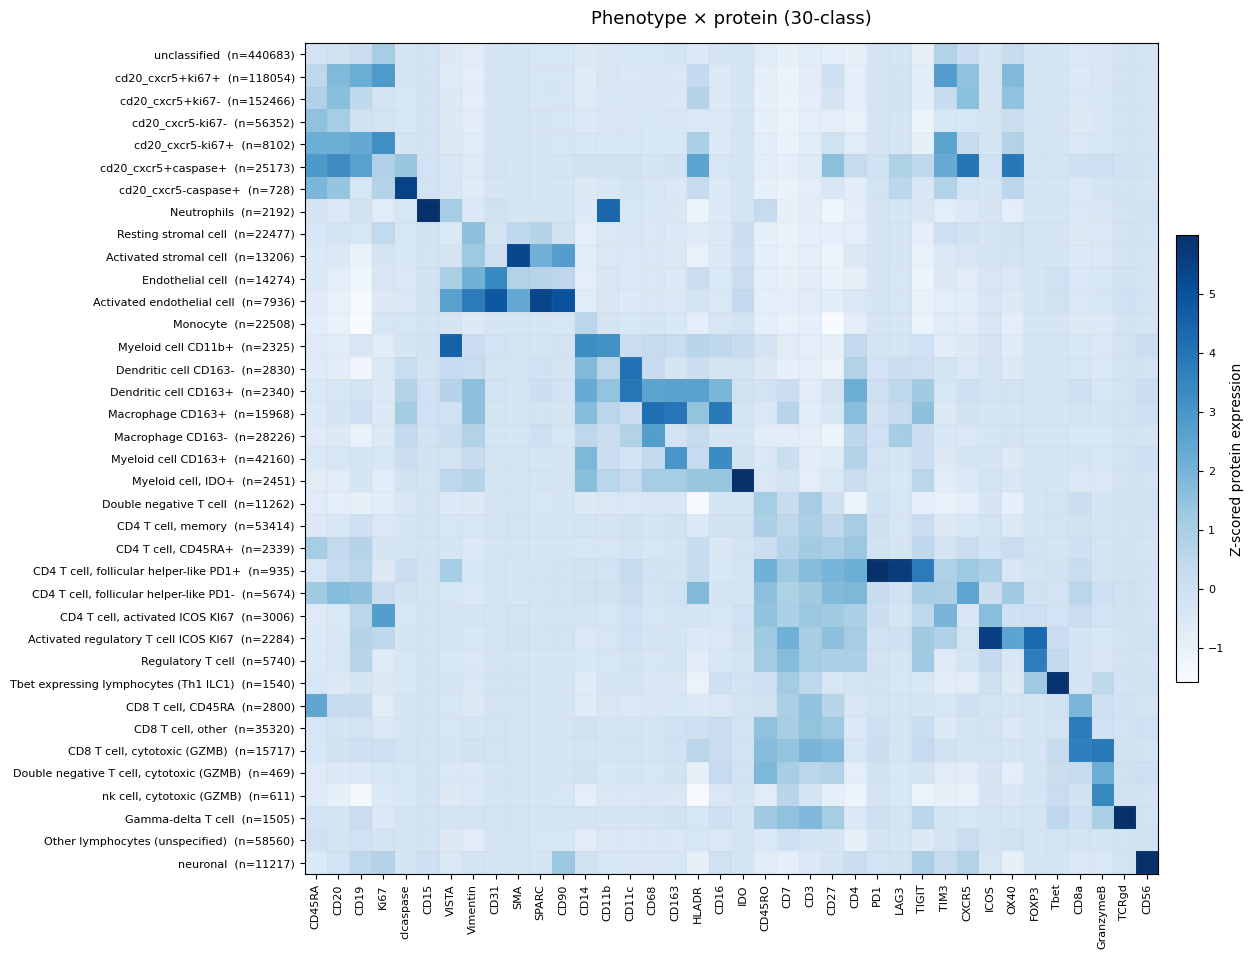

figures/supplemental_fig2/figS1K_phenotype30_protein_heatmap.svg


In [11]:
from dlbcl.phenotype_labels import PHENOTYPE_30_HEATMAP_ORDER as PHENO_30_ORDER
PROTEINS_30 = [
    "CD45RA", "CD20", "CD19", "Ki67", "clcaspase", "CD15", "VISTA", "Vimentin", "CD31", "SMA",
    "SPARC", "CD90", "CD14", "CD11b", "CD11c", "CD68", "CD163", "HLADR", "CD16", "IDO", "CD45RO",
    "CD7", "CD3", "CD27", "CD4", "PD1", "LAG3", "TIGIT", "TIM3", "CXCR5", "ICOS", "OX40", "FOXP3",
    "Tbet", "CD8a", "GranzymeB", "TCRgd", "CD56",
]

M30, rows30, cols30, counts30 = build_pheno_protein_matrix(
    adata_subset, "phenotype_30_clean", PHENO_30_ORDER, PROTEINS_30, layer=IMC_LAYER,
)
Mz30 = _zscore_rows(M30, axis=0)
plot_pheno_protein_heatmap(
    Mz30, rows30, cols30, counts30,
    title="Phenotype × protein (30-class)",
    out_path=FIG_DIR / "figS1K_phenotype30_protein_heatmap.svg",
)


## Fig S2M — phenotype × protein (16-class, coarse)

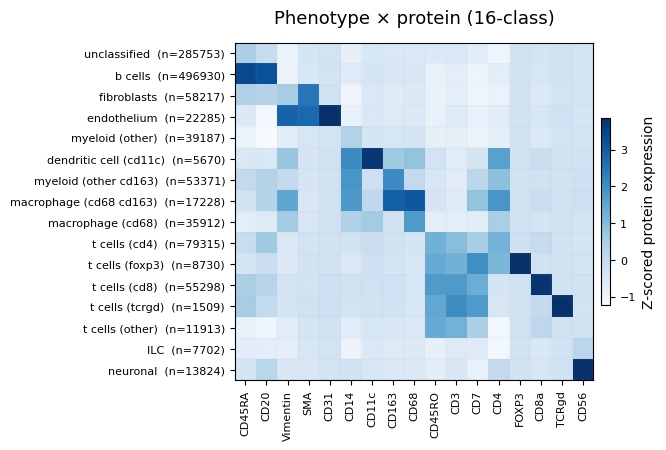

figures/supplemental_fig2/figS1L_phenotype16_protein_heatmap.svg


In [12]:
PHENO_16_ORDER = [
    "unclassified", "b cells", "neutrophils", "fibroblasts", "endothelium", "myofibroblast",
    "myeloid (other)", "dendritic cell (cd11c)", "myeloid (other cd163)",
    "macrophage (cd68 cd163)", "macrophage (cd68)", "t cells (cd4)", "t cells (foxp3)",
    "t cells (cd8)", "t cells (tcrgd)", "t cells (other)", "ILC", "other CD45", "neuronal",
]
PROTEINS_16 = [
    "CD45RA", "CD20", "Vimentin", "SMA", "CD31", "CD14", "CD11c", "CD163", "CD68", "CD45RO",
    "CD3", "CD7", "CD4", "FOXP3", "CD8a", "TCRgd", "CD56",
]

M16, rows16, cols16, counts16 = build_pheno_protein_matrix(
    adata_subset, "phenotype_16_clean", PHENO_16_ORDER, PROTEINS_16, layer=IMC_LAYER,
)
Mz16 = _zscore_rows(M16, axis=0)
plot_pheno_protein_heatmap(
    Mz16, rows16, cols16, counts16,
    title="Phenotype × protein (16-class)",
    out_path=FIG_DIR / "figS1L_phenotype16_protein_heatmap.svg",
)
